## 1. Imports, Environment Setup, and Directory Paths


In [5]:
# %% [1] Imports and Paths
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from scipy.io import loadmat

sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 11

# این نوت‌بوک داخل پوشه notebooks فرض شده
DATA_DIR   = os.path.abspath("../data")
RAW_DIR    = os.path.join(DATA_DIR, "raw")
SPLITS_DIR = os.path.join(DATA_DIR, "splits")

os.makedirs(SPLITS_DIR, exist_ok=True)

print("DATA_DIR:  ", DATA_DIR)
print("RAW_DIR:   ", RAW_DIR)
print("SPLITS_DIR:", SPLITS_DIR)


DATA_DIR:   c:\Users\Anexpectant\Documents\aut\karshenasi\final_project\projects\main_project\Single_Lead_ECG_AF_Classification\data
RAW_DIR:    c:\Users\Anexpectant\Documents\aut\karshenasi\final_project\projects\main_project\Single_Lead_ECG_AF_Classification\data\raw
SPLITS_DIR: c:\Users\Anexpectant\Documents\aut\karshenasi\final_project\projects\main_project\Single_Lead_ECG_AF_Classification\data\splits


## 2. Load REFERENCE.csv and Match .mat File Paths

In [6]:
# %% [2] Load REFERENCE.csv and map to .mat files (robust)
ref_path = os.path.join(RAW_DIR, "REFERENCE.csv")

# REFERENCE.csv معمولاً بدون header است: col0=record_id, col1=label
df_ref = pd.read_csv(ref_path, header=None, names=["record_id", "label"])

# record_idها در REFERENCE مثل: A00/A00001
# ما باید clean_id = A00001 بسازیم تا با نام فایل‌ها مچ شود
df_ref["record_id"] = df_ref["record_id"].astype(str).str.strip()
df_ref["clean_id"] = df_ref["record_id"].apply(lambda x: os.path.basename(x))

# پیدا کردن همه فایل‌های .mat
mat_files = glob.glob(os.path.join(RAW_DIR, "**", "*.mat"), recursive=True)
print("Total .mat files found:", len(mat_files))

# map: A00001 -> full_path_to_mat
path_map = {os.path.splitext(os.path.basename(p))[0]: p for p in mat_files}

df_ref["file_path"] = df_ref["clean_id"].map(path_map)

total = len(df_ref)
matched = df_ref["file_path"].notna().sum()
missing = total - matched

print(f"Total reference rows: {total}")
print(f"Matched .mat files:   {matched}")
print(f"Missing:             {missing}")

# اگر چیزی مچ نشد، نمونه‌اش را چاپ کن
if missing > 0:
    print("\nSample missing rows:")
    print(df_ref[df_ref["file_path"].isna()][["record_id","clean_id","label"]].head(20))

# در حالت درست باید missing=0 باشد
assert missing == 0, "Some records in REFERENCE.csv do not have corresponding .mat files."

# برای ادامه کار، record_id را همان clean_id می‌گیریم (A00001)
df_ref["record_id"] = df_ref["clean_id"]
df_ref.drop(columns=["clean_id"], inplace=True)

# نام خوانا برای کلاس‌ها
class_names = {"N":"Normal (N)", "A":"AF (A)", "O":"Other (O)", "~":"Noisy (~)"}
df_ref["class_name"] = df_ref["label"].map(class_names)

df_ref.head()


Total .mat files found: 8528
Total reference rows: 8528
Matched .mat files:   8528
Missing:             0


,record_id,label,file_path,class_name
0,A00001,N,c:\Users\Anexpectant\Documents\aut\karshenasi\...,Normal (N)
1,A00002,N,c:\Users\Anexpectant\Documents\aut\karshenasi\...,Normal (N)
2,A00003,N,c:\Users\Anexpectant\Documents\aut\karshenasi\...,Normal (N)
3,A00004,A,c:\Users\Anexpectant\Documents\aut\karshenasi\...,AF (A)
4,A00005,A,c:\Users\Anexpectant\Documents\aut\karshenasi\...,AF (A)


## 3. Stratified Split Generation (Train/Val/Test) and CSV Export


In [7]:
# %% [3] Make Stratified Train/Val/Test splits and save CSVs
RANDOM_SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

assert abs((VAL_RATIO + TEST_RATIO) - (1 - TRAIN_RATIO)) < 1e-9

# Train vs Temp (Val+Test)
train_df, temp_df = train_test_split(
    df_ref,
    test_size=(1 - TRAIN_RATIO),
    random_state=RANDOM_SEED,
    stratify=df_ref["label"]
)

# Val vs Test from temp
val_df, test_df = train_test_split(
    temp_df,
    test_size=(TEST_RATIO / (VAL_RATIO + TEST_RATIO)),  # یعنی 0.5 وقتی val=test
    random_state=RANDOM_SEED,
    stratify=temp_df["label"]
)

# ذخیره
train_path = os.path.join(SPLITS_DIR, "train.csv")
val_path   = os.path.join(SPLITS_DIR, "val.csv")
test_path  = os.path.join(SPLITS_DIR, "test.csv")

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print("✅ Saved splits:")
print(" -", train_path, "->", len(train_df))
print(" -", val_path,   "->", len(val_df))
print(" -", test_path,  "->", len(test_df))

print("\nRatios:")
print("Train:", len(train_df)/len(df_ref))
print("Val:  ", len(val_df)/len(df_ref))
print("Test: ", len(test_df)/len(df_ref))


✅ Saved splits:
 - c:\Users\Anexpectant\Documents\aut\karshenasi\final_project\projects\main_project\Single_Lead_ECG_AF_Classification\data\splits\train.csv -> 5969
 - c:\Users\Anexpectant\Documents\aut\karshenasi\final_project\projects\main_project\Single_Lead_ECG_AF_Classification\data\splits\val.csv -> 1279
 - c:\Users\Anexpectant\Documents\aut\karshenasi\final_project\projects\main_project\Single_Lead_ECG_AF_Classification\data\splits\test.csv -> 1280

Ratios:
Train: 0.6999296435272045
Val:   0.1499765478424015
Test:  0.150093808630394


## 4. Data Leakage Verification and Overlap Checks


In [8]:
# %% [4] Data leakage check (record_id overlap)
train_ids = set(train_df["record_id"])
val_ids   = set(val_df["record_id"])
test_ids  = set(test_df["record_id"])

ov_tr_va = train_ids & val_ids
ov_tr_te = train_ids & test_ids
ov_va_te = val_ids & test_ids

print("Overlap Train/Val :", len(ov_tr_va))
print("Overlap Train/Test:", len(ov_tr_te))
print("Overlap Val/Test  :", len(ov_va_te))

assert len(ov_tr_va) == 0, "Leakage between Train and Val!"
assert len(ov_tr_te) == 0, "Leakage between Train and Test!"
assert len(ov_va_te) == 0, "Leakage between Val and Test!"

print("✅ No data leakage detected.")


Overlap Train/Val : 0
Overlap Train/Test: 0
Overlap Val/Test  : 0
✅ No data leakage detected.


## 5. Target Class Distribution and Visualization Across Splits



--- Class Count Table ---
label    A     N     O    ~
split                      
Test   113   762   363   42
Train  531  3553  1690  195
Val    114   761   362   42

--- Class Percent Table (%) ---
label     A      N      O     ~
split                          
Test   8.83  59.53  28.36  3.28
Train  8.90  59.52  28.31  3.27
Val    8.91  59.50  28.30  3.28


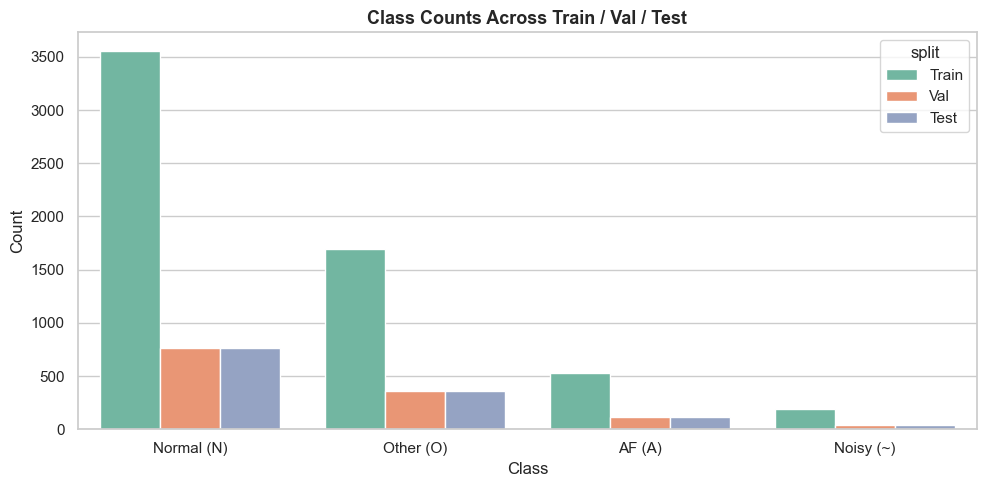

In [9]:
# %% [5] Class distribution across splits
train_df_plot = train_df.copy(); train_df_plot["split"] = "Train"
val_df_plot   = val_df.copy();   val_df_plot["split"]   = "Val"
test_df_plot  = test_df.copy();  test_df_plot["split"]  = "Test"

full_df = pd.concat([train_df_plot, val_df_plot, test_df_plot], ignore_index=True)

# Count table
count_tbl = pd.crosstab(full_df["split"], full_df["label"])
pct_tbl   = pd.crosstab(full_df["split"], full_df["label"], normalize="index") * 100

print("\n--- Class Count Table ---")
print(count_tbl)

print("\n--- Class Percent Table (%) ---")
print(pct_tbl.round(2))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=full_df, x="class_name", hue="split", palette="Set2", ax=ax)
ax.set_title("Class Counts Across Train / Val / Test", fontsize=13, fontweight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## 6. ECG Signal Duration Analysis and Distribution Plots


      length_seconds                                                    \
               count       mean        std       min   25%   50%   75%   
split                                                                    
Test          1280.0  32.353531  10.980308  9.126667  30.0  30.0  30.0   
Train         5969.0  32.501755  10.836180  9.046667  30.0  30.0  30.0   
Val           1279.0  32.621506  11.051886  9.360000  30.0  30.0  30.0   

                  
             max  
split             
Test   60.720000  
Train  60.953333  
Val    60.793333  


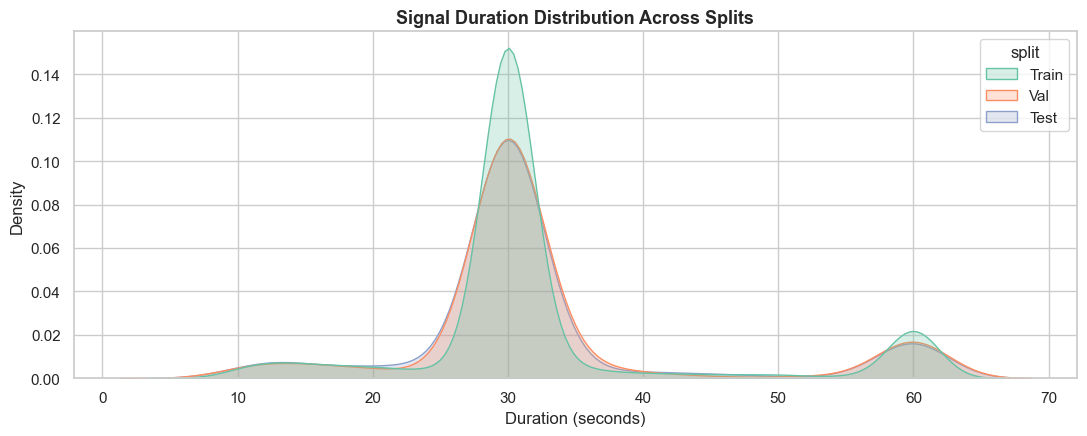

C:\Users\Anexpectant\AppData\Local\Temp\ipykernel_17832\4151785769.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


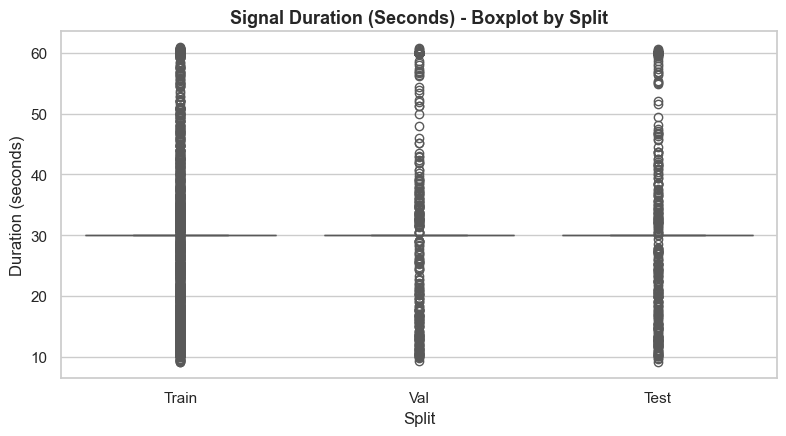

In [11]:
# %% [6] Signal length distribution across splits
FS = 300.0  # sampling rate

def get_len_samples(mat_path):
    x = loadmat(mat_path)["val"][0]
    return int(len(x))

# برای سرعت: فقط همین ستون‌ها لازم است
full_df_small = full_df[["record_id", "label", "class_name", "split", "file_path"]].copy()

# محاسبه طول‌ها
full_df_small["length_samples"] = full_df_small["file_path"].apply(get_len_samples)
full_df_small["length_seconds"] = full_df_small["length_samples"] / FS

print(full_df_small[["split", "length_seconds"]].groupby("split").describe())

# KDE Plot
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.kdeplot(
    data=full_df_small,
    x="length_seconds",
    hue="split",
    common_norm=False,
    fill=True,
    alpha=0.25,
    palette="Set2",
    ax=ax
)
ax.set_title("Signal Duration Distribution Across Splits", fontsize=13, fontweight="bold")
ax.set_xlabel("Duration (seconds)")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

# Boxplot
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(
    data=full_df_small, 
    x="split", 
    y="length_seconds", 
    palette="Set2", 
    ax=ax
)
ax.set_title("Signal Duration (Seconds) - Boxplot by Split", fontsize=13, fontweight="bold")
ax.set_xlabel("Split")
ax.set_ylabel("Duration (seconds)")
plt.tight_layout()
plt.show()


## 7. Statistical Summary Table for Thesis and Reports


In [12]:
# %% [7] Summary table for thesis/report
summary = (full_df_small
           .groupby(["split","class_name"])
           .agg(
               Count=("record_id","count"),
               Mean_s=("length_seconds","mean"),
               Std_s=("length_seconds","std"),
               Min_s=("length_seconds","min"),
               Max_s=("length_seconds","max"),
           )
           .reset_index())

summary["Mean_s"] = summary["Mean_s"].round(2)
summary["Std_s"]  = summary["Std_s"].round(2)
summary["Min_s"]  = summary["Min_s"].round(2)
summary["Max_s"]  = summary["Max_s"].round(2)

summary


,split,class_name,Count,Mean_s,Std_s,Min_s,Max_s
0,Test,AF (A),113,32.11,12.43,10.06,60.00
1,Test,Noisy (~),42,23.29,9.32,10.03,56.33
2,Test,Normal (N),762,32.46,10.57,9.76,60.72
3,Test,Other (O),363,33.25,11.10,9.13,60.27
4,Train,AF (A),531,32.01,12.10,9.99,60.21
5,Train,Noisy (~),195,24.80,10.59,10.21,60.00
6,Train,Normal (N),3553,32.05,9.81,9.05,60.95
7,Train,Other (O),1690,34.49,11.94,9.49,60.86
8,Val,AF (A),114,34.14,13.17,10.68,60.00
9,Val,Noisy (~),42,23.50,10.81,9.36,60.00
